<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import pandas as pd

In [63]:
import numpy as np

In [64]:
import matplotlib.pyplot as plt

In [65]:
import seaborn as sns

In [66]:
dfSucio=pd.read_csv("dataset_sucio_practica.csv")

In [67]:
dfSucio.shape

(125, 8)

In [68]:
dfSucio.head()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [69]:
dfSucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    object 
 2   edad            110 non-null    float64
 3   correo          125 non-null    object 
 4   pais            82 non-null     object 
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    object 
 7   activo          90 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.9+ KB


In [70]:
# Generamos una copia de seguridad por cualquier cosa
dfCopy = dfSucio.copy()

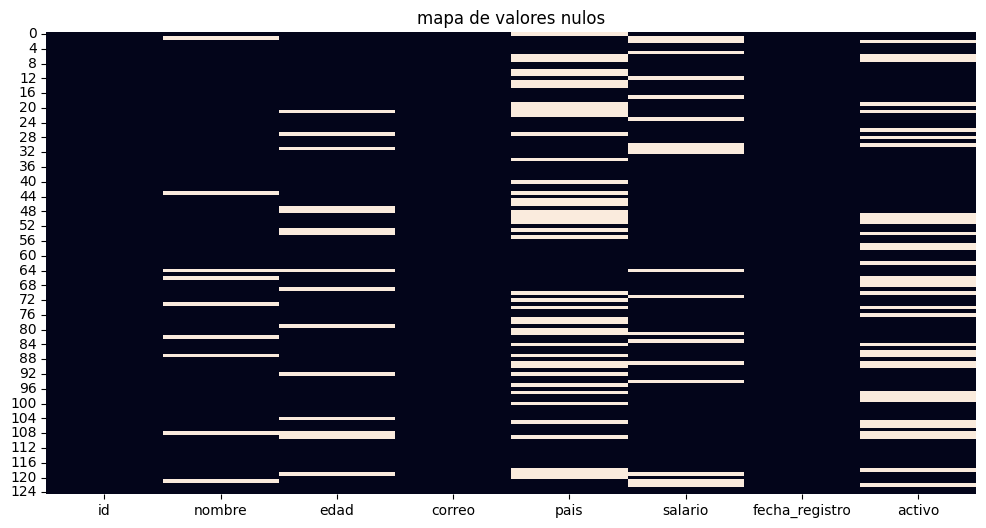

In [71]:
plt.figure(figsize = (12,6))
sns.heatmap(dfSucio.isnull(), cbar = False)
plt.title("mapa de valores nulos")
plt.show()

In [72]:
# Verificamos cuántos duplicados hay
print(dfSucio.duplicated().sum())

5


In [73]:
# Borramos datos duplicados
dfSucio.drop_duplicates(inplace=True)

In [74]:
# Verificamos cuántos duplicados hay
print(dfSucio.duplicated().sum())

0


In [75]:
# Reemplazar por nulo
dfSucio.loc[(dfSucio["edad"] < 0) | (dfSucio["edad"] > 110), "edad"] = np.nan

In [76]:
# Calcular la mediana y rellenar
mediana_edad = dfSucio["edad"].median()
dfSucio["edad"] = dfSucio["edad"].fillna(mediana_edad)

In [89]:
mediana_edad

30.0

In [77]:
# Verificar
dfSucio["edad"].describe()

,edad
count,120.000000
mean,30.325000
std,4.745918
min,22.000000
25%,30.000000
50%,30.000000
75%,31.250000
max,40.000000


In [78]:
# Reemplazar salarios negativos por nulo
dfSucio.loc[(dfSucio["salario"] < 0), "salario"] = np.nan

In [79]:
# Calcular mediana y rellenar
mediana_salario = dfSucio["salario"].median()
dfSucio["salario"] = dfSucio["salario"].fillna(mediana_salario)

In [90]:
mediana_salario

15000.0

In [80]:
# Verificar
dfSucio["salario"].describe()

,salario
count,120.000000
mean,16741.666667
std,4401.099621
min,12000.000000
25%,15000.000000
50%,15000.000000
75%,18000.000000
max,25000.000000


In [81]:
# Identificar correos que no tienen "@" y marcarlos como nulos (NA)
correo_invalido = ~dfSucio["correo"].str.contains("@", na=False)
dfSucio.loc[correo_invalido, "correo"] = pd.NA

In [92]:
correo_invalido

,correo
0,False
1,False
2,False
3,True
4,True
...,...
115,False
116,False
117,False
118,False


In [82]:
# Calcular moda y rellenar
moda_pais = dfSucio["pais"].mode()[0]
dfSucio["pais"] = dfSucio["pais"].fillna(moda_pais)

In [91]:
moda_pais

'Argentina'

In [83]:
# Convertimos fecha a datetime
dfSucio["fecha_registro"] = pd.to_datetime(dfSucio["fecha_registro"])

In [84]:
# Comprobamos los tipos de datos
dfSucio.dtypes

,0
id,int64
nombre,object
edad,float64
correo,object
pais,object
salario,float64
fecha_registro,datetime64[ns]
activo,object


In [85]:
# Rellenar nulos con "Sí"
dfSucio["activo"] = dfSucio["activo"].fillna("Sí")

In [86]:
# Convertir a binario (1 y 0)
dfSucio["activo"] = dfSucio["activo"].map({
    "Sí": 1,
    "No": 0
})

In [87]:
# Verificar
dfSucio["activo"].value_counts(dropna=False)

,count
activo,
1,81
0,39


In [88]:
(dfSucio.isnull().sum() / len(dfSucio)) * 100

,0
id,0.000000
nombre,6.666667
edad,0.000000
correo,10.000000
pais,0.000000
salario,0.000000
fecha_registro,0.000000
activo,0.000000


Conclusiones
Durante la práctica se identificaron y corrigieron los siguientes problemas:

    Eliminar los datos duplicados.

    Corregir datos inválidos y atípicos.

    Realizar y corregir tipos de datos.

    Categorizar campos que sean necesarios.